# EHA Clinics — Tier 1 & 2 Demand Forecasting Models

**Project:** Procurement Demand Forecasting Initiative  
**KPI target:** MAPE ≤ 20% for critical health commodities across pilot facilities by Q3  

This notebook implements and evaluates the first two tiers of the forecasting framework defined in the Scope & Modelling Approach concept note:

| Tier | Models | Role |
|---|---|---|
| **1 — Benchmark** | Seasonal Naïve, 12-Month Rolling Average | Establish Q2 MAPE baseline; set the performance floor |
| **2 — Classical** | ETS (Holt-Winters), SARIMA, Theta Method | Primary modelling candidates |

**EDA-informed decisions applied throughout:**
- Kano — Independence Road 2021 is excluded from all training (bulk stock-load event, Sep 2021: 258,470 units)
- Training window: Jan 2021 – Dec 2023 (post-COVID stable baseline)
- Validation window: Jan 2024 – Jun 2024 (official Q2 baseline measurement)
- Only Tier A (≥ 24 non-zero months) and Tier B (12–23 months) pairs are modelled; Tier C pairs are flagged for fixed-interval ordering
- Laboratory Consumables are flagged as high financial-risk regardless of MAPE rank
- MAPE is computed only on non-zero months to avoid division-by-zero on sparse series

In [20]:
import warnings
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 130,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
})

BLUE, GREEN, RED, AMBER = '#00548E', '#009976', '#C0392B', '#E67E22'
PALETTE = [BLUE, GREEN, RED, AMBER, '#8E44AD', '#1ABC9C']

print('All imports OK.')

All imports OK.


In [21]:
# ── Project root resolution (works whether run from project root or scripts/) ──
PROJECT_ROOT = Path().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'data').exists(), f'Cannot find data/ under {PROJECT_ROOT}'

DATA_DIR    = PROJECT_ROOT / 'data'
REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

# ── Scope constants (mirrors eda_analysis.py) ─────────────────────────────────
INSCOPE_CATS = {
    'Prescription Medications', 'Over The Counter Drugs',
    'Vaccines', 'NPI Vaccines', 'Injections',
    'Medical Consumables', 'Laboratory Consumables',
    'Dental Consumables', 'Consumables',
}

PILOT = {
    'Abuja - Asba and Dantata',
    'Abuja - Lugbe',
    'Kano - Lamido Crescent',
    'Kano - Independence Road',
    'Lagos - Sangotedo Ajah',
    'REACH Abuja Hub 1 Clinic - Kuje',
}

SHORT_NAMES = {
    'Abuja - Asba and Dantata':        'Asba (Abuja)',
    'Abuja - Lugbe':                   'Lugbe (Abuja)',
    'Kano - Lamido Crescent':          'Lamido (Kano)',
    'Kano - Independence Road':        'Indep. Rd (Kano)',
    'Lagos - Sangotedo Ajah':          'Sangotedo (Lagos)',
    'REACH Abuja Hub 1 Clinic - Kuje': 'REACH Kuje',
}

SHORT_CATS = {
    'Prescription Medications': 'Rx Meds',
    'Over The Counter Drugs':   'OTC Drugs',
    'Medical Consumables':      'Med. Consumables',
    'Laboratory Consumables':   'Lab Consumables',
    'Consumables':              'Consumables',
    'Injections':               'Injections',
    'Vaccines':                 'Vaccines',
    'NPI Vaccines':             'NPI Vaccines',
    'Dental Consumables':       'Dental Consumables',
}

HIGH_RISK_CATS = {'Laboratory Consumables'}  # high unit cost — flag even at MAPE ≤ 20%

# ── Time windows ──────────────────────────────────────────────────────────────
TRAIN_START = pd.Timestamp('2021-01-01')
TRAIN_END   = pd.Timestamp('2023-12-01')
VAL_START   = pd.Timestamp('2024-01-01')
VAL_END     = pd.Timestamp('2024-06-01')
H           = 6   # validation horizon (months)

# Walk-forward CV folds (within training window)
CV_FOLDS = [
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-01'), pd.Timestamp('2023-01-01'), pd.Timestamp('2023-06-01')),
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2023-06-01'), pd.Timestamp('2023-07-01'), pd.Timestamp('2023-12-01')),
]

print(f'Project root : {PROJECT_ROOT}')
print(f'Data dir     : {DATA_DIR}')

Project root : C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling
Data dir     : C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling\data


## 1. Data Loading & Preparation

Replicates the EDA filtering pipeline and adds the monthly aggregation and zero-fill steps required for time-series modelling.

In [22]:
print('Loading data...')
df_raw = pd.read_csv(DATA_DIR / 'Clinics Procurement Data.csv', low_memory=False)

df_raw['date_order']    = pd.to_datetime(df_raw['date_order'], errors='coerce')
df_raw['month']         = pd.to_datetime(df_raw['month'],      errors='coerce')
df_raw['product_qty']   = pd.to_numeric(df_raw['product_qty'],   errors='coerce').fillna(0)
df_raw['price_subtotal']= pd.to_numeric(df_raw['price_subtotal'],errors='coerce').fillna(0)
df_raw['year']          = pd.to_numeric(df_raw['year'],          errors='coerce')

# Apply all EDA-defined filters
df = df_raw[
    (df_raw['state'] == 'done') &
    (df_raw['product_qty'] > 0) &
    (df_raw['price_subtotal'] >= 0) &
    df_raw['category_name'].isin(INSCOPE_CATS) &
    df_raw['branch_name'].isin(PILOT)
].copy()

# EDA Finding #2: exclude Kano Independence Road 2021 bulk stock-load event
bulk_mask = (df['branch_name'] == 'Kano - Independence Road') & (df['year'] == 2021)
n_excluded = bulk_mask.sum()
df = df[~bulk_mask].copy()

df['branch_short'] = df['branch_name'].map(SHORT_NAMES)
df['cat_short']    = df['category_name'].map(SHORT_CATS)

print(f'  Filtered records  : {len(df):,}  (excluded {n_excluded:,} Kano Indep. Rd 2021 bulk rows)')
print(f'  Facilities        : {df["branch_name"].nunique()}')
print(f'  Categories        : {df["category_name"].nunique()}')
print(f'  Date range        : {df["month"].min().date()} to {df["month"].max().date()}')

Loading data...
  Filtered records  : 8,458  (excluded 365 Kano Indep. Rd 2021 bulk rows)
  Facilities        : 6
  Categories        : 9
  Date range        : 2020-01-01 to 2025-03-01


In [23]:
# ── Monthly aggregation ───────────────────────────────────────────────────────
monthly_raw = (
    df.groupby(['category_name', 'branch_name', 'month'])['product_qty']
    .sum().reset_index()
)

# Complete time index for the full analysis window (train + validation)
full_index = pd.date_range(TRAIN_START, VAL_END, freq='MS')

# Zero-fill gaps: every category-facility pair gets an entry for every month
all_pairs = monthly_raw[['category_name', 'branch_name']].drop_duplicates()
records = []
for _, row in all_pairs.iterrows():
    sub = (
        monthly_raw[
            (monthly_raw['category_name'] == row['category_name']) &
            (monthly_raw['branch_name']   == row['branch_name'])
        ]
        .set_index('month')['product_qty']
        .reindex(full_index, fill_value=0)
    )
    sub.index.name = 'month'
    sub = sub.reset_index()
    sub['category_name'] = row['category_name']
    sub['branch_name']   = row['branch_name']
    records.append(sub)

df_monthly = pd.concat(records, ignore_index=True)
df_monthly['branch_short'] = df_monthly['branch_name'].map(SHORT_NAMES)
df_monthly['cat_short']    = df_monthly['category_name'].map(SHORT_CATS)

print(f'Monthly series built: {len(df_monthly):,} rows')
print(f'  Pairs  : {len(all_pairs)}')
print(f'  Months : {len(full_index)}  ({full_index[0].date()} to {full_index[-1].date()})')

Monthly series built: 1,890 rows
  Pairs  : 45
  Months : 42  (2021-01-01 to 2024-06-01)


In [24]:
# ── Train / validation split ──────────────────────────────────────────────────
df_train = df_monthly[df_monthly['month'].between(TRAIN_START, TRAIN_END)].copy()
df_val   = df_monthly[df_monthly['month'].between(VAL_START,   VAL_END  )].copy()

# ── Pair readiness classification (from EDA Section 9) ───────────────────────
nz_months = (
    df_train[df_train['product_qty'] > 0]
    .groupby(['category_name', 'branch_name'])['month']
    .nunique().reset_index()
    .rename(columns={'month': 'nz_months'})
)

def classify(n):
    if n >= 24: return 'A'
    if n >= 12: return 'B'
    return 'C'

nz_months['readiness'] = nz_months['nz_months'].apply(classify)
nz_months['branch_short'] = nz_months['branch_name'].map(SHORT_NAMES)
nz_months['cat_short']    = nz_months['category_name'].map(SHORT_CATS)
nz_months['high_risk']    = nz_months['category_name'].isin(HIGH_RISK_CATS)

# Only model Tier A and B pairs
eligible = nz_months[nz_months['readiness'].isin(['A', 'B'])].copy()
tier_c   = nz_months[nz_months['readiness'] == 'C'].copy()

print(f'Pair readiness summary:')
print(f'  Tier A (>=24 months) : {(nz_months["readiness"]=="A").sum():>3} pairs  — primary modelling candidates')
print(f'  Tier B (12-23 months): {(nz_months["readiness"]=="B").sum():>3} pairs  — modelled with simpler configs')
print(f'  Tier C (<12 months)  : {(nz_months["readiness"]=="C").sum():>3} pairs  — excluded from forecasting')
print(f'\nTotal eligible pairs for modelling: {len(eligible)}')

Pair readiness summary:
  Tier A (>=24 months) :  13 pairs  — primary modelling candidates
  Tier B (12-23 months):   2 pairs  — modelled with simpler configs
  Tier C (<12 months)  :  28 pairs  — excluded from forecasting

Total eligible pairs for modelling: 15


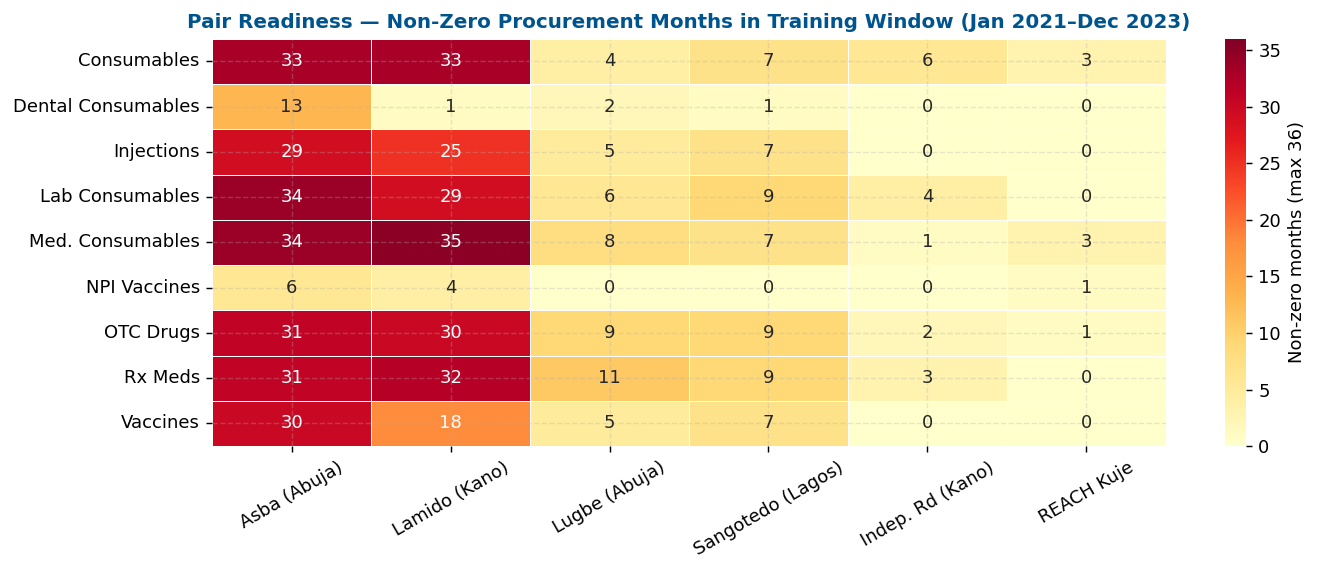

In [25]:
# ── Readiness heatmap ─────────────────────────────────────────────────────────
pivot = nz_months.pivot_table(
    index='cat_short', columns='branch_short', values='nz_months', fill_value=0
)

col_order = ['Asba (Abuja)', 'Lamido (Kano)', 'Lugbe (Abuja)',
             'Sangotedo (Lagos)', 'Indep. Rd (Kano)', 'REACH Kuje']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(pivot, ax=ax, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Non-zero months (max 36)'},
            vmin=0, vmax=36)
ax.set_title('Pair Readiness — Non-Zero Procurement Months in Training Window (Jan 2021–Dec 2023)',
             color=BLUE, fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 2. Helper Functions

All model functions share a common signature: `fn(train_series, h) -> np.ndarray`  
MAPE is computed only on non-zero actual months (avoiding division by zero on sparse series).

In [26]:
def mape(actual: np.ndarray, forecast: np.ndarray) -> float:
    """MAPE ignoring zero-actual periods."""
    actual   = np.asarray(actual,   dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    mask = actual > 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100)


def get_pair_series(cat, branch, split_df):
    """Return a sorted Series indexed by month for one category-facility pair."""
    sub = split_df[
        (split_df['category_name'] == cat) &
        (split_df['branch_name']   == branch)
    ].sort_values('month').set_index('month')['product_qty']
    return sub


def walk_forward_mape(model_fn, cat, branch, folds=CV_FOLDS):
    """
    Walk-forward cross-validation within the training window.
    Returns mean MAPE across folds, or np.nan if all folds fail.
    """
    fold_mapes = []
    for (tr_start, tr_end, val_s, val_e) in folds:
        tr  = df_monthly[
            (df_monthly['category_name'] == cat) &
            (df_monthly['branch_name']   == branch) &
            df_monthly['month'].between(tr_start, tr_end)
        ].sort_values('month').set_index('month')['product_qty']

        val = df_monthly[
            (df_monthly['category_name'] == cat) &
            (df_monthly['branch_name']   == branch) &
            df_monthly['month'].between(val_s, val_e)
        ].sort_values('month').set_index('month')['product_qty']

        h_fold = len(val)
        if len(tr) < 12 or h_fold == 0:
            continue
        try:
            fc = model_fn(tr, h_fold)
            fold_mapes.append(mape(val.values, fc))
        except Exception:
            continue

    valid = [m for m in fold_mapes if not np.isnan(m)]
    return float(np.mean(valid)) if valid else np.nan


def final_mape(model_fn, cat, branch):
    """
    Train on full training window, forecast validation window.
    Returns (forecast_series, MAPE).
    """
    train = get_pair_series(cat, branch, df_train)
    val   = get_pair_series(cat, branch, df_val)
    if len(train) < 12:
        return None, np.nan
    try:
        fc = model_fn(train, len(val))
        fc = np.maximum(fc, 0)  # clip negatives
        fc_series = pd.Series(fc, index=val.index)
        return fc_series, mape(val.values, fc)
    except Exception:
        return None, np.nan


print('Helper functions defined.')

Helper functions defined.


## 3. Tier 1 — Benchmark Models

These models require no fitting. They establish the Q2 MAPE baseline that all Tier 2 models must beat to justify their complexity.

In [27]:
def seasonal_naive(train: pd.Series, h: int) -> np.ndarray:
    """
    Seasonal Naïve: forecast[t] = actual[t - 12].
    Falls back to series mean for lags that fall before the training start.
    """
    vals = train.values
    n    = len(vals)
    fc   = []
    for i in range(h):
        lag_idx = n - 12 + i
        fc.append(vals[lag_idx] if lag_idx >= 0 else np.mean(vals))
    return np.array(fc)


def rolling_average(train: pd.Series, h: int, window: int = 12) -> np.ndarray:
    """
    12-Month Rolling Average: forecast is the mean of the last 12 months.
    """
    avg = float(train.tail(window).mean())
    return np.full(h, avg)


print('Tier 1 models defined: Seasonal Naïve, 12-Month Rolling Average')

Tier 1 models defined: Seasonal Naïve, 12-Month Rolling Average


In [28]:
# ── Run Tier 1 on all eligible pairs ─────────────────────────────────────────
print('Running Tier 1 benchmarks...')
tier1_rows = []

for _, row in eligible.iterrows():
    cat, branch = row['category_name'], row['branch_name']

    cv_sn        = walk_forward_mape(seasonal_naive,  cat, branch)
    fc_sn, vm_sn = final_mape(seasonal_naive,         cat, branch)
    cv_ra        = walk_forward_mape(rolling_average,  cat, branch)
    fc_ra, vm_ra = final_mape(rolling_average,         cat, branch)

    def _r(v):
        return round(v, 1) if pd.notna(v) else np.nan

    tier1_rows.append({
        'category':     cat,
        'branch':       branch,
        'cat_short':    row['cat_short'],
        'branch_short': row['branch_short'],
        'readiness':    row['readiness'],
        'high_risk':    row['high_risk'],
        'nz_months':    row['nz_months'],
        'sn_cv_mape':   _r(cv_sn),
        'sn_val_mape':  _r(vm_sn),
        'ra_cv_mape':   _r(cv_ra),
        'ra_val_mape':  _r(vm_ra),
        'fc_sn':        fc_sn,
        'fc_ra':        fc_ra,
    })

tier1 = pd.DataFrame(tier1_rows)
tier1['t1_best_mape'] = tier1[['sn_val_mape', 'ra_val_mape']].min(axis=1)

def _pick_t1_model(r):
    sn_ok = pd.notna(r['sn_val_mape'])
    ra_ok = pd.notna(r['ra_val_mape'])
    if sn_ok and ra_ok:
        return 'Seasonal Naïve' if r['sn_val_mape'] <= r['ra_val_mape'] else 'Rolling Average'
    if sn_ok:  return 'Seasonal Naïve'
    if ra_ok:  return 'Rolling Average'
    return 'N/A'

tier1['t1_best_model'] = tier1.apply(_pick_t1_model, axis=1)

meets_t1 = (tier1['t1_best_mape'] <= 20).sum()
print(f'Done. {len(tier1)} pairs evaluated.')
print(f'Pairs meeting MAPE ≤ 20% at Tier 1: {meets_t1} / {len(tier1)}')

Running Tier 1 benchmarks...
Done. 15 pairs evaluated.
Pairs meeting MAPE ≤ 20% at Tier 1: 0 / 15


In [29]:
# ── Tier 1 Results Table ──────────────────────────────────────────────────────
display_cols = ['cat_short', 'branch_short', 'readiness', 'nz_months',
                'sn_val_mape', 'ra_val_mape', 't1_best_mape', 't1_best_model']

t1_display = tier1[display_cols].rename(columns={
    'cat_short':     'Category',
    'branch_short':  'Facility',
    'readiness':     'Tier',
    'nz_months':     'Non-zero months',
    'sn_val_mape':   'Seasonal Naïve MAPE',
    'ra_val_mape':   'Rolling Avg MAPE',
    't1_best_mape':  'Best T1 MAPE',
    't1_best_model': 'Best T1 Model',
}).sort_values('Best T1 MAPE')

def colour_mape(val):
    if pd.isna(val):   return ''
    if val <= 20:      return 'background-color: #d4edda; color: #155724'
    if val <= 40:      return 'background-color: #fff3cd; color: #856404'
    return                    'background-color: #f8d7da; color: #721c24'

styled = (
    t1_display.style
    .map(colour_mape, subset=['Seasonal Naïve MAPE', 'Rolling Avg MAPE', 'Best T1 MAPE'])
    .set_caption('Tier 1 Benchmark Results — Validation MAPE (Jan–Jun 2024)')
    .format({'Seasonal Naïve MAPE': '{:.1f}%', 'Rolling Avg MAPE': '{:.1f}%',
             'Best T1 MAPE': '{:.1f}%'}, na_rep='—')
)
display(styled)

,Category,Facility,Tier,Non-zero months,Seasonal Naïve MAPE,Rolling Avg MAPE,Best T1 MAPE,Best T1 Model
7,Med. Consumables,Asba (Abuja),A,34,85.3%,73.2%,73.2%,Rolling Average
8,Med. Consumables,Lamido (Kano),A,35,79.4%,1200.1%,79.4%,Seasonal Naïve
14,Vaccines,Lamido (Kano),B,18,100.0%,81.2%,81.2%,Rolling Average
1,Consumables,Lamido (Kano),A,33,84.8%,347.7%,84.8%,Seasonal Naïve
0,Consumables,Asba (Abuja),A,33,84.9%,356.4%,84.9%,Seasonal Naïve
2,Dental Consumables,Asba (Abuja),B,13,97.0%,91.4%,91.4%,Rolling Average
13,Vaccines,Asba (Abuja),A,30,137.0%,115.0%,115.0%,Rolling Average
3,Injections,Asba (Abuja),A,29,121.9%,277.2%,121.9%,Seasonal Naïve
11,Rx Meds,Asba (Abuja),A,31,131.9%,195.1%,131.9%,Seasonal Naïve
9,OTC Drugs,Asba (Abuja),A,31,144.0%,135.2%,135.2%,Rolling Average


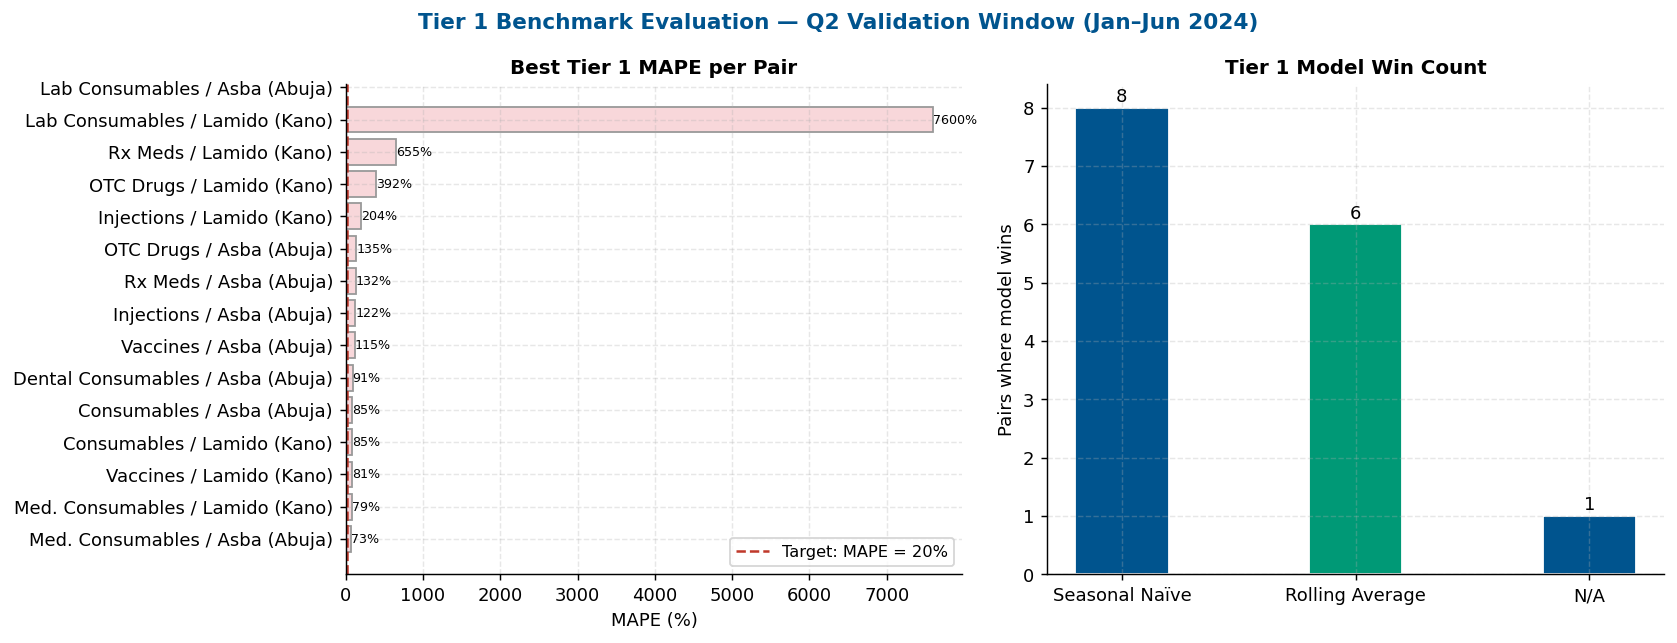

In [30]:
# ── Tier 1 MAPE Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: MAPE per pair (sorted)
t1_sorted = tier1.sort_values('t1_best_mape')
labels = t1_sorted['cat_short'] + ' / ' + t1_sorted['branch_short']
colours = ['#d4edda' if m <= 20 else '#fff3cd' if m <= 40 else '#f8d7da'
           for m in t1_sorted['t1_best_mape']]
bars = axes[0].barh(labels, t1_sorted['t1_best_mape'], color=colours, edgecolor='#999')
axes[0].axvline(20, color=RED, linestyle='--', linewidth=1.4, label='Target: MAPE = 20%')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('Best Tier 1 MAPE per Pair')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, t1_sorted['t1_best_mape']):
    if not np.isnan(val):
        axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', va='center', fontsize=7)

# Right: Model win counts
wins = tier1['t1_best_model'].value_counts()
axes[1].bar(wins.index, wins.values, color=[BLUE, GREEN], edgecolor='white', width=0.4)
for i, v in enumerate(wins.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10)
axes[1].set_ylabel('Pairs where model wins')
axes[1].set_title('Tier 1 Model Win Count')

fig.suptitle('Tier 1 Benchmark Evaluation — Q2 Validation Window (Jan–Jun 2024)',
             fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tier1_results.pdf', bbox_inches='tight')
plt.show()

## 4. Tier 2 — Classical Time Series Models

Three models are evaluated. Each is fitted independently per category-facility pair.

| Model | Key characteristic | EDA relevance |
|---|---|---|
| **ETS (Holt-Winters)** | Decomposes into error, trend, seasonal | Handles the Q4 Harmattan OTC peak; auto-selects additive vs multiplicative |
| **SARIMA** | Captures autocorrelation + seasonal differencing | Handles carry-over demand / stockout suppression effects |
| **Theta** | Linear trend + SES recombination | Fast; competitive on stationary series (EDA confirms stationarity post-2021) |

> **SARIMA runtime note:** A small candidate grid is used (5 orders) to keep execution manageable. Tier A pairs run the full candidate set; Tier B pairs default to `(0,1,1)(0,1,1,12)` which is the most robust seasonal specification for short series.

In [31]:
def ets_forecast(train: pd.Series, h: int) -> np.ndarray:
    """
    ETS with automatic component selection.
    Tries (additive trend + additive seasonal) first, degrades gracefully.
    """
    configs = [
        ('add', 'add', 12),
        ('add', None, None),
        (None,  'add', 12),
        (None,  None,  None),
    ]
    for trend, seasonal, sp in configs:
        try:
            model = ExponentialSmoothing(
                train,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=sp,
                initialization_method='estimated'
            ).fit(optimized=True, remove_bias=True)
            return np.maximum(model.forecast(h), 0)
        except Exception:
            continue
    return np.full(h, float(train.mean()))


SARIMA_CANDIDATES_A = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 0, 12)),
    ((1, 1, 1), (1, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
]
SARIMA_DEFAULT = ((0, 1, 1), (0, 1, 1, 12))  # fast default for Tier B


def sarima_forecast(train: pd.Series, h: int, tier: str = 'A') -> np.ndarray:
    """
    SARIMA: selects best order by AIC from candidate set (Tier A)
    or uses a fast default (Tier B).
    """
    candidates = SARIMA_CANDIDATES_A if tier == 'A' else [SARIMA_DEFAULT]
    best_aic, best_order, best_seasonal = np.inf, (0, 1, 1), (0, 1, 1, 12)

    for order, seasonal in candidates:
        try:
            res = SARIMAX(
                train, order=order, seasonal_order=seasonal,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
            if res.aic < best_aic:
                best_aic, best_order, best_seasonal = res.aic, order, seasonal
        except Exception:
            continue

    try:
        final = SARIMAX(
            train, order=best_order, seasonal_order=best_seasonal,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)
        return np.maximum(final.forecast(h), 0)
    except Exception:
        return np.full(h, float(train.mean()))


def theta_forecast(train: pd.Series, h: int) -> np.ndarray:
    """
    Theta method (Assimakopoulos & Nikolopoulos, 2000).
    Theta_0 = linear extrapolation of long-run trend.
    Theta_2 = SES-smoothed short-run variation.
    Forecast = 0.5 * Theta_0 + 0.5 * Theta_2
    """
    y = train.values.astype(float)
    n = len(y)
    t = np.arange(1, n + 1)

    # Theta_0: linear regression extrapolation
    a, b   = np.polyfit(t, y, 1)
    t_fut  = np.arange(n + 1, n + h + 1)
    theta0 = a * t_fut + b

    # Theta_2: SES with optimised alpha
    try:
        ses    = SimpleExpSmoothing(y, initialization_method='estimated').fit(optimized=True)
        theta2 = ses.forecast(h)
    except Exception:
        theta2 = np.full(h, y.mean())

    return np.maximum(0.5 * theta0 + 0.5 * theta2, 0)


print('Tier 2 models defined: ETS, SARIMA, Theta')

Tier 2 models defined: ETS, SARIMA, Theta


In [32]:
# ── Run Tier 2 on all eligible pairs ─────────────────────────────────────────
# SARIMA is the slowest step (~1-3 min total for all Tier A pairs)
print('Running Tier 2 models (ETS, SARIMA, Theta)...')
print('SARIMA grid search on Tier A pairs may take 1–3 minutes.')

tier2_rows = []
for seq, (_, row) in enumerate(eligible.iterrows(), start=1):
    cat, branch, tier_ab = row['category_name'], row['branch_name'], row['readiness']

    # Wrap SARIMA to pass tier info
    def sarima_ab(train, h, _tier=tier_ab):
        return sarima_forecast(train, h, tier=_tier)

    # Validation MAPEs
    fc_ets,   vm_ets   = final_mape(ets_forecast,  cat, branch)
    fc_sarima,vm_sarima= final_mape(sarima_ab,     cat, branch)
    fc_theta, vm_theta = final_mape(theta_forecast, cat, branch)

    # Walk-forward CV MAPEs
    cv_ets    = walk_forward_mape(ets_forecast,   cat, branch)
    cv_sarima = walk_forward_mape(sarima_ab,      cat, branch)
    cv_theta  = walk_forward_mape(theta_forecast, cat, branch)

    tier2_rows.append({
        'category':       cat,
        'branch':         branch,
        'cat_short':      row['cat_short'],
        'branch_short':   row['branch_short'],
        'readiness':      tier_ab,
        'high_risk':      row['high_risk'],
        'ets_cv':         round(cv_ets,    1),
        'ets_val':        round(vm_ets,    1),
        'sarima_cv':      round(cv_sarima, 1),
        'sarima_val':     round(vm_sarima, 1),
        'theta_cv':       round(cv_theta,  1),
        'theta_val':      round(vm_theta,  1),
        'fc_ets':         fc_ets,
        'fc_sarima':      fc_sarima,
        'fc_theta':       fc_theta,
    })
    print(f'  [{seq:02d}/{len(eligible)}] {row["cat_short"]:20s} @ {row["branch_short"]:20s}  '
          f'ETS={vm_ets:5.1f}%  SARIMA={vm_sarima:5.1f}%  Theta={vm_theta:5.1f}%')

tier2 = pd.DataFrame(tier2_rows)
tier2['t2_best_mape']  = tier2[['ets_val', 'sarima_val', 'theta_val']].min(axis=1)
tier2['t2_best_model'] = tier2.apply(
    lambda r: min(
        [('ETS', r['ets_val']), ('SARIMA', r['sarima_val']), ('Theta', r['theta_val'])],
        key=lambda x: (np.inf if np.isnan(x[1]) else x[1])
    )[0], axis=1
)

meets_t2 = (tier2['t2_best_mape'] <= 20).sum()
print(f'\nDone. Pairs meeting MAPE ≤ 20% at Tier 2: {meets_t2} / {len(tier2)}')

Running Tier 2 models (ETS, SARIMA, Theta)...
SARIMA grid search on Tier A pairs may take 1–3 minutes.
  [01/15] Consumables          @ Asba (Abuja)          ETS=100.0%  SARIMA=163.5%  Theta=100.0%
  [02/15] Consumables          @ Lamido (Kano)         ETS= 78.7%  SARIMA=1539.0%  Theta= 81.3%
  [03/15] Dental Consumables   @ Asba (Abuja)          ETS= 91.8%  SARIMA= 91.3%  Theta= 91.4%
  [04/15] Injections           @ Asba (Abuja)          ETS= 85.0%  SARIMA=1269.9%  Theta=491.2%
  [05/15] Injections           @ Lamido (Kano)         ETS=384.7%  SARIMA=240.0%  Theta=515.5%
  [06/15] Lab Consumables      @ Asba (Abuja)          ETS=  nan%  SARIMA=  nan%  Theta=  nan%
  [07/15] Lab Consumables      @ Lamido (Kano)         ETS=7493.2%  SARIMA=17518.8%  Theta=6549.0%
  [08/15] Med. Consumables     @ Asba (Abuja)          ETS=100.0%  SARIMA=100.0%  Theta= 77.9%
  [09/15] Med. Consumables     @ Lamido (Kano)         ETS= 96.7%  SARIMA= 66.4%  Theta= 99.8%
  [10/15] OTC Drugs            @ Asb

In [33]:
# ── Tier 2 Results Table ──────────────────────────────────────────────────────
t2_display = tier2[['cat_short', 'branch_short', 'readiness',
                     'ets_val', 'sarima_val', 'theta_val',
                     't2_best_mape', 't2_best_model']].rename(columns={
    'cat_short':    'Category',
    'branch_short': 'Facility',
    'readiness':    'Tier',
    'ets_val':      'ETS MAPE',
    'sarima_val':   'SARIMA MAPE',
    'theta_val':    'Theta MAPE',
    't2_best_mape': 'Best T2 MAPE',
    't2_best_model':'Best T2 Model',
}).sort_values('Best T2 MAPE')

mape_cols = ['ETS MAPE', 'SARIMA MAPE', 'Theta MAPE', 'Best T2 MAPE']
styled2 = (
    t2_display.style
    .map(colour_mape, subset=mape_cols)
    .set_caption('Tier 2 Classical Model Results — Validation MAPE (Jan–Jun 2024)')
    .format({c: '{:.1f}%' for c in mape_cols})
)
display(styled2)

,Category,Facility,Tier,ETS MAPE,SARIMA MAPE,Theta MAPE,Best T2 MAPE,Best T2 Model
14,Vaccines,Lamido (Kano),B,44.8%,49.3%,71.8%,44.8%,ETS
8,Med. Consumables,Lamido (Kano),A,96.7%,66.4%,99.8%,66.4%,SARIMA
9,OTC Drugs,Asba (Abuja),A,73.0%,275.4%,85.6%,73.0%,ETS
7,Med. Consumables,Asba (Abuja),A,100.0%,100.0%,77.9%,77.9%,Theta
1,Consumables,Lamido (Kano),A,78.7%,1539.0%,81.3%,78.7%,ETS
11,Rx Meds,Asba (Abuja),A,86.7%,475.0%,80.7%,80.7%,Theta
13,Vaccines,Asba (Abuja),A,82.9%,92.3%,140.5%,82.9%,ETS
3,Injections,Asba (Abuja),A,85.0%,1269.9%,491.2%,85.0%,ETS
2,Dental Consumables,Asba (Abuja),B,91.8%,91.3%,91.4%,91.3%,SARIMA
12,Rx Meds,Lamido (Kano),A,806.6%,237.5%,100.0%,100.0%,Theta


## 5. Full Model Comparison & Best Model Selection

All five models are compared side-by-side per pair. The best model overall is selected as the one achieving the **lowest validation MAPE**. Pairs that already met the target at Tier 1 are flagged — the Tier 2 model is still reported for completeness but the simpler model is preferred (in line with the tiered complexity principle).

In [34]:
# ── Merge Tier 1 and Tier 2 results ──────────────────────────────────────────
merged = tier1[['category', 'branch', 'cat_short', 'branch_short',
                'readiness', 'high_risk', 'nz_months',
                'sn_val_mape', 'ra_val_mape', 't1_best_mape', 't1_best_model',
                'fc_sn', 'fc_ra']].merge(
    tier2[['category', 'branch',
           'ets_val', 'sarima_val', 'theta_val', 't2_best_mape', 't2_best_model',
           'fc_ets', 'fc_sarima', 'fc_theta']],
    on=['category', 'branch'], how='outer'
)

_col_to_name = {
    'sn_val_mape':  'Seasonal Naïve',
    'ra_val_mape':  'Rolling Average',
    'ets_val':      'ETS',
    'sarima_val':   'SARIMA',
    'theta_val':    'Theta',
}

all_mapes = merged[['sn_val_mape', 'ra_val_mape', 'ets_val', 'sarima_val', 'theta_val']]

merged['overall_best_mape']  = all_mapes.min(axis=1)

# idxmin raises ValueError on all-NaN rows in pandas 2.x — use apply instead
def _best_model_name(row):
    valid = row.dropna()
    return _col_to_name[valid.idxmin()] if not valid.empty else np.nan

merged['overall_best_model'] = all_mapes.apply(_best_model_name, axis=1)

# Apply tiered complexity principle: prefer simpler model if already ≤ 20%
def preferred_model(row):
    t1_ok = pd.notna(row['t1_best_mape']) and row['t1_best_mape'] <= 20
    t2_ok = pd.notna(row['t2_best_mape']) and row['t2_best_mape'] <= 20
    if t1_ok:
        return row['t1_best_model'] + ' ✓ (Tier 1 sufficient)'
    if t2_ok:
        return row['t2_best_model'] + ' (Tier 2)'
    if pd.notna(row['overall_best_model']):
        return str(row['overall_best_model']) + ' — below target ⚠'
    return 'No valid model — series all-zero ⚠'

merged['recommended_model'] = merged.apply(preferred_model, axis=1)
merged['meets_target']      = merged['overall_best_mape'] <= 20

meets = merged['meets_target'].sum()
print(f'Pairs meeting MAPE ≤ 20% (any model): {meets} / {len(merged)}')
print(f'Pairs still above target             : {len(merged) - meets} / {len(merged)}  → escalate to Tier 3 (Prophet)')

Pairs meeting MAPE ≤ 20% (any model): 0 / 15
Pairs still above target             : 15 / 15  → escalate to Tier 3 (Prophet)


In [36]:
# ── Full Comparison Table ─────────────────────────────────────────────────────
comp_display = merged[['cat_short', 'branch_short', 'readiness', 'nz_months',
                        'sn_val_mape', 'ra_val_mape',
                        'ets_val', 'sarima_val', 'theta_val',
                        'overall_best_mape', 'recommended_model', 'high_risk']].rename(columns={
    'cat_short':          'Category',
    'branch_short':       'Facility',
    'readiness':          'Tier',
    'nz_months':          'Months',
    'sn_val_mape':        'Seas. Naïve',
    'ra_val_mape':        'Roll. Avg',
    'ets_val':            'ETS',
    'sarima_val':         'SARIMA',
    'theta_val':          'Theta',
    'overall_best_mape':  'Best MAPE',
    'recommended_model':  'Recommended Model',
    'high_risk':          'High Risk $',
}).sort_values('Best MAPE')

mape_cols_all = ['Seas. Naïve', 'Roll. Avg', 'ETS', 'SARIMA', 'Theta', 'Best MAPE']
styled_comp = (
    comp_display.style
    .map(colour_mape, subset=mape_cols_all)
    .set_caption('Full Model Comparison — All 5 Models × All Eligible Pairs (Validation MAPE %)')
    .format({c: '{:.1f}%' for c in mape_cols_all})
)
display(styled_comp)

,Category,Facility,Tier,Months,Seas. Naïve,Roll. Avg,ETS,SARIMA,Theta,Best MAPE,Recommended Model,High Risk $
14,Vaccines,Lamido (Kano),B,18,100.0%,81.2%,44.8%,49.3%,71.8%,44.8%,ETS — below target ⚠,False
8,Med. Consumables,Lamido (Kano),A,35,79.4%,1200.1%,96.7%,66.4%,99.8%,66.4%,SARIMA — below target ⚠,False
9,OTC Drugs,Asba (Abuja),A,31,144.0%,135.2%,73.0%,275.4%,85.6%,73.0%,ETS — below target ⚠,False
7,Med. Consumables,Asba (Abuja),A,34,85.3%,73.2%,100.0%,100.0%,77.9%,73.2%,Rolling Average — below target ⚠,False
1,Consumables,Lamido (Kano),A,33,84.8%,347.7%,78.7%,1539.0%,81.3%,78.7%,ETS — below target ⚠,False
11,Rx Meds,Asba (Abuja),A,31,131.9%,195.1%,86.7%,475.0%,80.7%,80.7%,Theta — below target ⚠,False
13,Vaccines,Asba (Abuja),A,30,137.0%,115.0%,82.9%,92.3%,140.5%,82.9%,ETS — below target ⚠,False
0,Consumables,Asba (Abuja),A,33,84.9%,356.4%,100.0%,163.5%,100.0%,84.9%,Seasonal Naïve — below target ⚠,False
3,Injections,Asba (Abuja),A,29,121.9%,277.2%,85.0%,1269.9%,491.2%,85.0%,ETS — below target ⚠,False
2,Dental Consumables,Asba (Abuja),B,13,97.0%,91.4%,91.8%,91.3%,91.4%,91.3%,SARIMA — below target ⚠,False


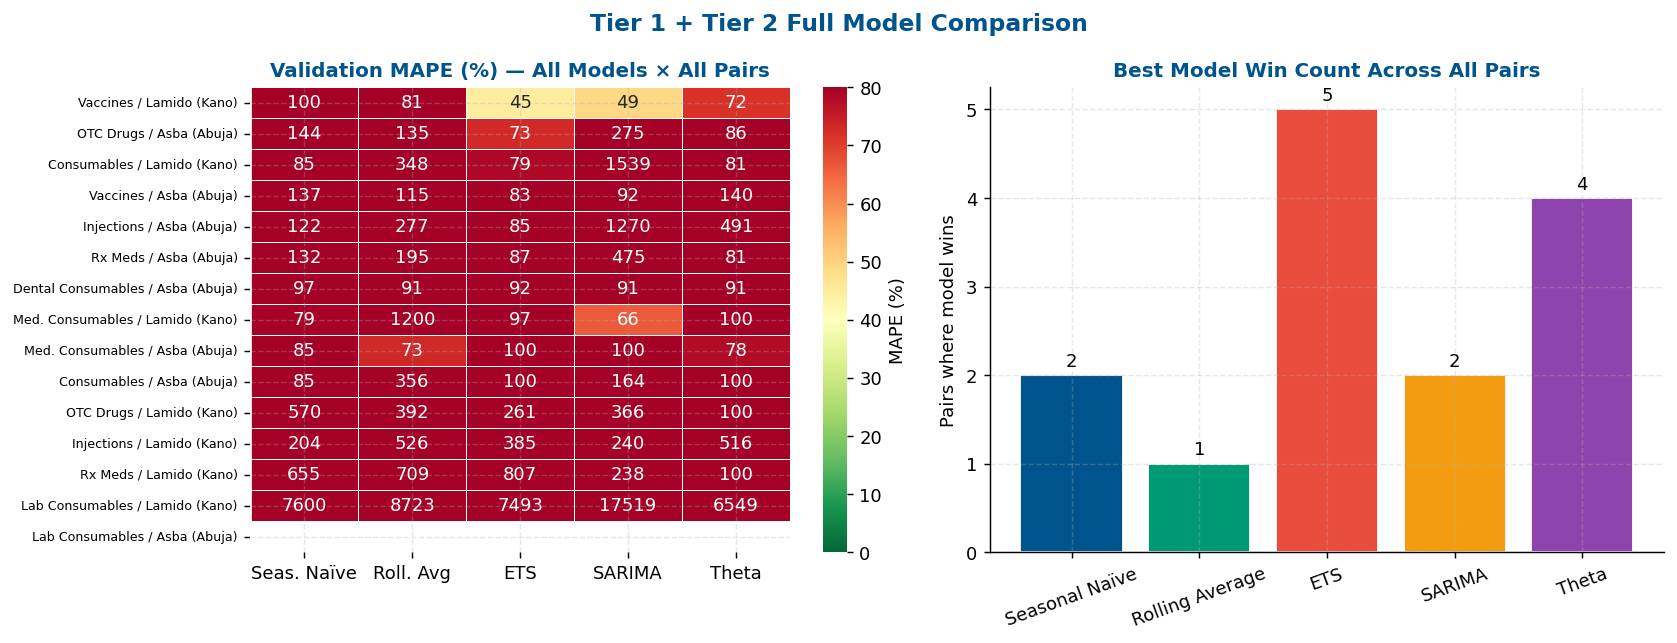

In [37]:
# ── Model Win Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: MAPE heatmap across all pairs and models
hmap_data = merged.set_index(
    merged['cat_short'] + ' / ' + merged['branch_short']
)[['sn_val_mape', 'ra_val_mape', 'ets_val', 'sarima_val', 'theta_val']].rename(columns={
    'sn_val_mape': 'Seas. Naïve',
    'ra_val_mape': 'Roll. Avg',
    'ets_val':     'ETS',
    'sarima_val':  'SARIMA',
    'theta_val':   'Theta',
}).sort_values('ETS')

sns.heatmap(hmap_data, ax=axes[0], cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'MAPE (%)'},
            vmin=0, vmax=80)
axes[0].axvline(x=0, color='white')
axes[0].set_title('Validation MAPE (%) — All Models × All Pairs', color=BLUE)
axes[0].tick_params(axis='y', labelsize=7)
axes[0].set_xlabel('')

# Right: Win counts
wins_all = merged['overall_best_model'].value_counts().reindex(
    ['Seasonal Naïve', 'Rolling Average', 'ETS', 'SARIMA', 'Theta'], fill_value=0
)
bar_colours = [BLUE, GREEN, '#E74C3C', '#F39C12', '#8E44AD']
axes[1].bar(wins_all.index, wins_all.values, color=bar_colours, edgecolor='white')
for i, v in enumerate(wins_all.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10)
axes[1].set_ylabel('Pairs where model wins')
axes[1].set_title('Best Model Win Count Across All Pairs', color=BLUE)
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('Tier 1 + Tier 2 Full Model Comparison',
             fontsize=13, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tier1_tier2_comparison.pdf', bbox_inches='tight')
plt.show()

## 6. Forecast Plots — Top Pairs

Visual inspection of the best-performing model's forecast vs. actual for the anchor facility pairs (Asba and Kano Lamido) across the primary categories.

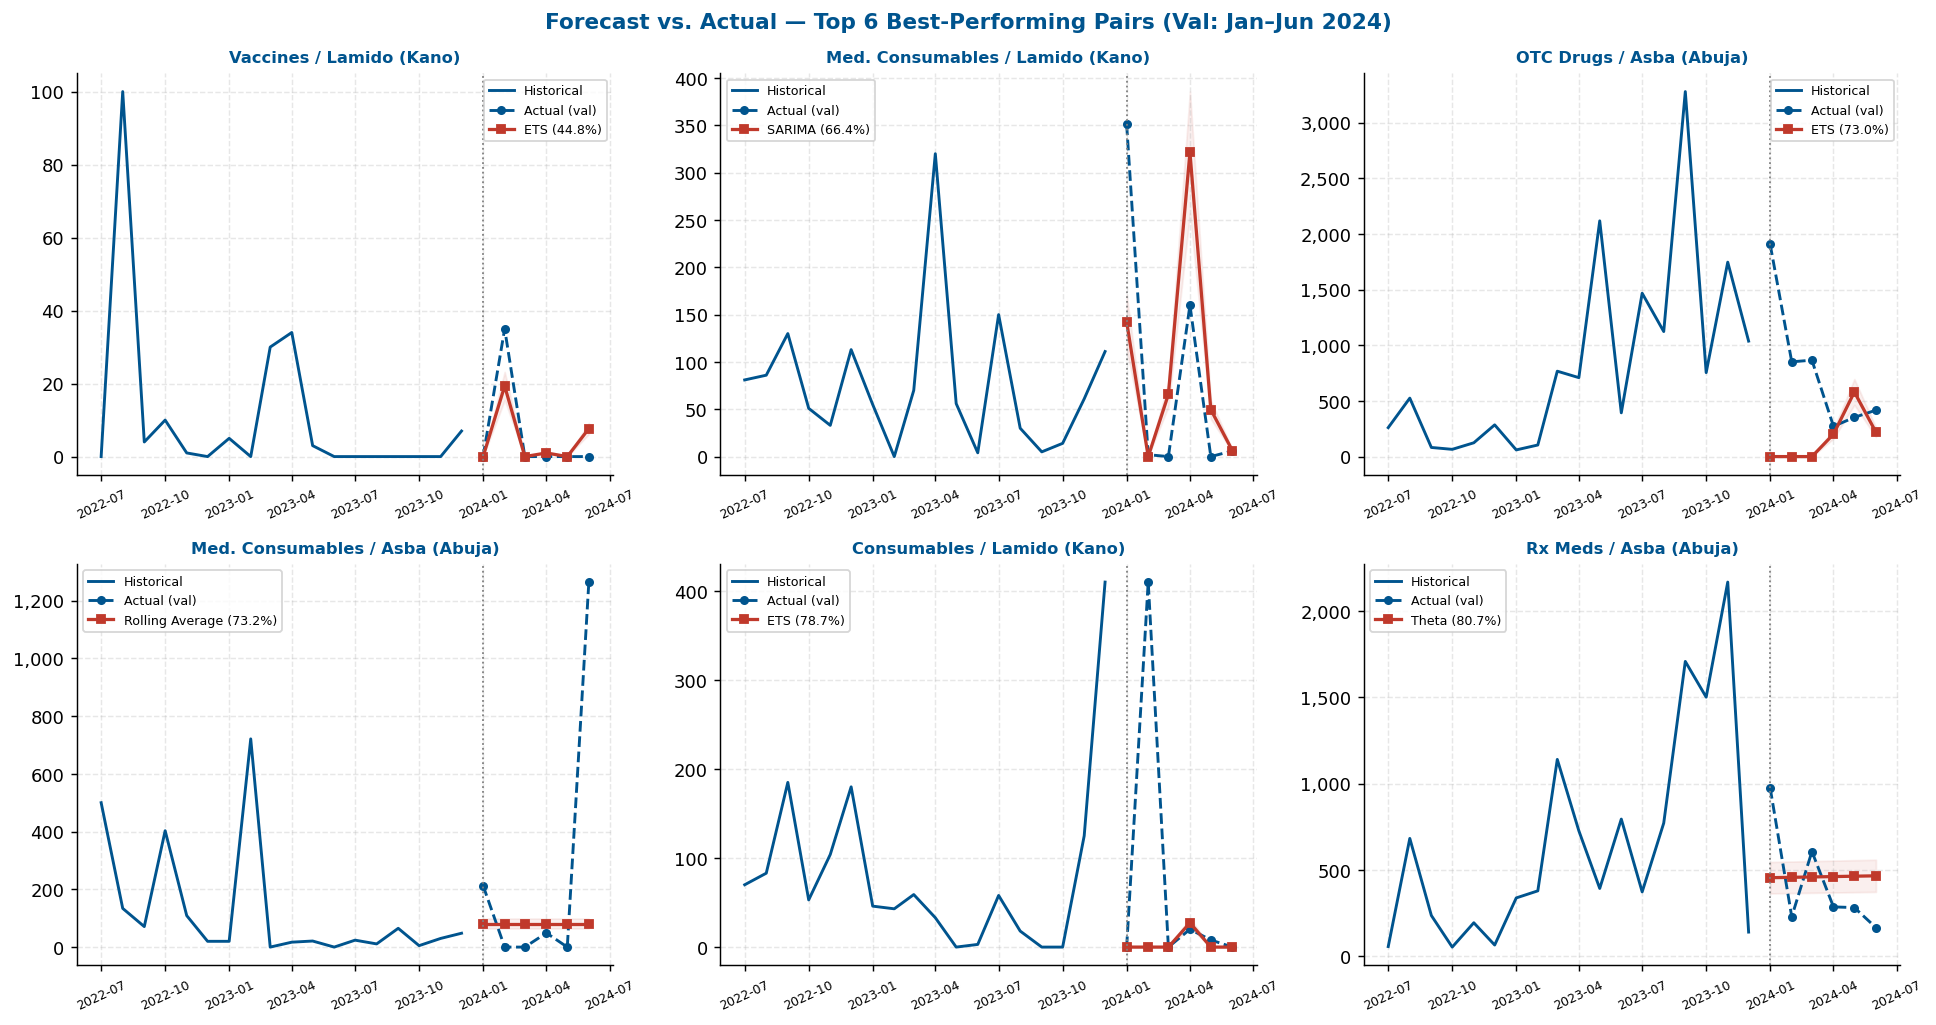

In [38]:
# Select top 6 pairs by overall best MAPE for plotting
top_pairs = merged.dropna(subset=['overall_best_mape']).sort_values('overall_best_mape').head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.flatten()

fc_map = {
    'Seasonal Naïve':  'fc_sn',
    'Rolling Average': 'fc_ra',
    'ETS':             'fc_ets',
    'SARIMA':          'fc_sarima',
    'Theta':           'fc_theta',
}

for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    cat, branch = row['category'], row['branch']
    train_s = get_pair_series(cat, branch, df_train)
    val_s   = get_pair_series(cat, branch, df_val)
    best_fc = row[fc_map[row['overall_best_model']]]

    # Plot last 18 months of training + validation
    ax.plot(train_s.index[-18:], train_s.values[-18:],
            color=BLUE, linewidth=1.6, label='Historical')
    ax.plot(val_s.index, val_s.values,
            color=BLUE, linewidth=1.6, linestyle='--', marker='o', markersize=4, label='Actual (val)')

    if best_fc is not None:
        ax.plot(best_fc.index, best_fc.values,
                color=RED, linewidth=1.8, linestyle='-', marker='s', markersize=4,
                label=f'{row["overall_best_model"]} ({row["overall_best_mape"]:.1f}%)')
        ax.fill_between(best_fc.index,
                         best_fc.values * 0.8, best_fc.values * 1.2,
                         color=RED, alpha=0.08)

    ax.axvline(val_s.index[0], color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'{row["cat_short"]} / {row["branch_short"]}', fontsize=9, color=BLUE)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=25, labelsize=7)

fig.suptitle('Forecast vs. Actual — Top 6 Best-Performing Pairs (Val: Jan–Jun 2024)',
             fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'top6_forecast_plots.pdf', bbox_inches='tight')
plt.show()

## 7. Q2 Baseline Report

This is the official Q2 deliverable: the MAPE baseline per category-facility pair, the recommended model, and which pairs require escalation to Tier 3 (Prophet).

In [39]:
# ── Q2 Baseline Summary ───────────────────────────────────────────────────────
tier_c_pairs = tier_c[['cat_short', 'branch_short', 'nz_months']].copy()
tier_c_pairs['status'] = 'Tier C — insufficient data; use fixed-interval ordering'

print('=' * 72)
print('  Q2 BASELINE MAPE REPORT — EHA Clinics Procurement Forecasting')
print('  Validation window: Jan 2024 – Jun 2024')
print('=' * 72)
print()
print(f'  Total pairs in scope            : {len(nz_months)}')
print(f'  Pairs modelled (Tier A + B)     : {len(merged)}')
print(f'  Pairs excluded (Tier C)         : {len(tier_c)}')
print()
print(f'  MAPE ≤ 20% at Tier 1            : {(tier1["t1_best_mape"] <= 20).sum()}')
print(f'  MAPE ≤ 20% at Tier 2            : {(tier2["t2_best_mape"] <= 20).sum()}')
print(f'  MAPE ≤ 20% (any model, Tier 1+2): {merged["meets_target"].sum()}')
print(f'  Pairs requiring Tier 3 (Prophet): {(~merged["meets_target"]).sum()}')
print()
print('  HIGH-RISK FINANCIAL PAIRS (Lab Consumables):')
hr = merged[merged['high_risk'] == True][['cat_short', 'branch_short', 'overall_best_mape', 'recommended_model']]
for _, r in hr.iterrows():
    if pd.notna(r['overall_best_mape']):
        flag     = '✓ TARGET MET' if r['overall_best_mape'] <= 20 else '⚠ ABOVE TARGET'
        mape_str = f'{r["overall_best_mape"]:5.1f}%'
    else:
        flag     = '⚠ NO DATA'
        mape_str = '  N/A '
    print(f'    {r["cat_short"]:20s} @ {r["branch_short"]:22s}  MAPE={mape_str}  {flag}')
print()
print('=' * 72)

  Q2 BASELINE MAPE REPORT — EHA Clinics Procurement Forecasting
  Validation window: Jan 2024 – Jun 2024

  Total pairs in scope            : 43
  Pairs modelled (Tier A + B)     : 15
  Pairs excluded (Tier C)         : 28

  MAPE ≤ 20% at Tier 1            : 0
  MAPE ≤ 20% at Tier 2            : 0
  MAPE ≤ 20% (any model, Tier 1+2): 0
  Pairs requiring Tier 3 (Prophet): 15

  HIGH-RISK FINANCIAL PAIRS (Lab Consumables):
    Lab Consumables      @ Asba (Abuja)            MAPE=  N/A   ⚠ NO DATA
    Lab Consumables      @ Lamido (Kano)           MAPE=6549.0%  ⚠ ABOVE TARGET



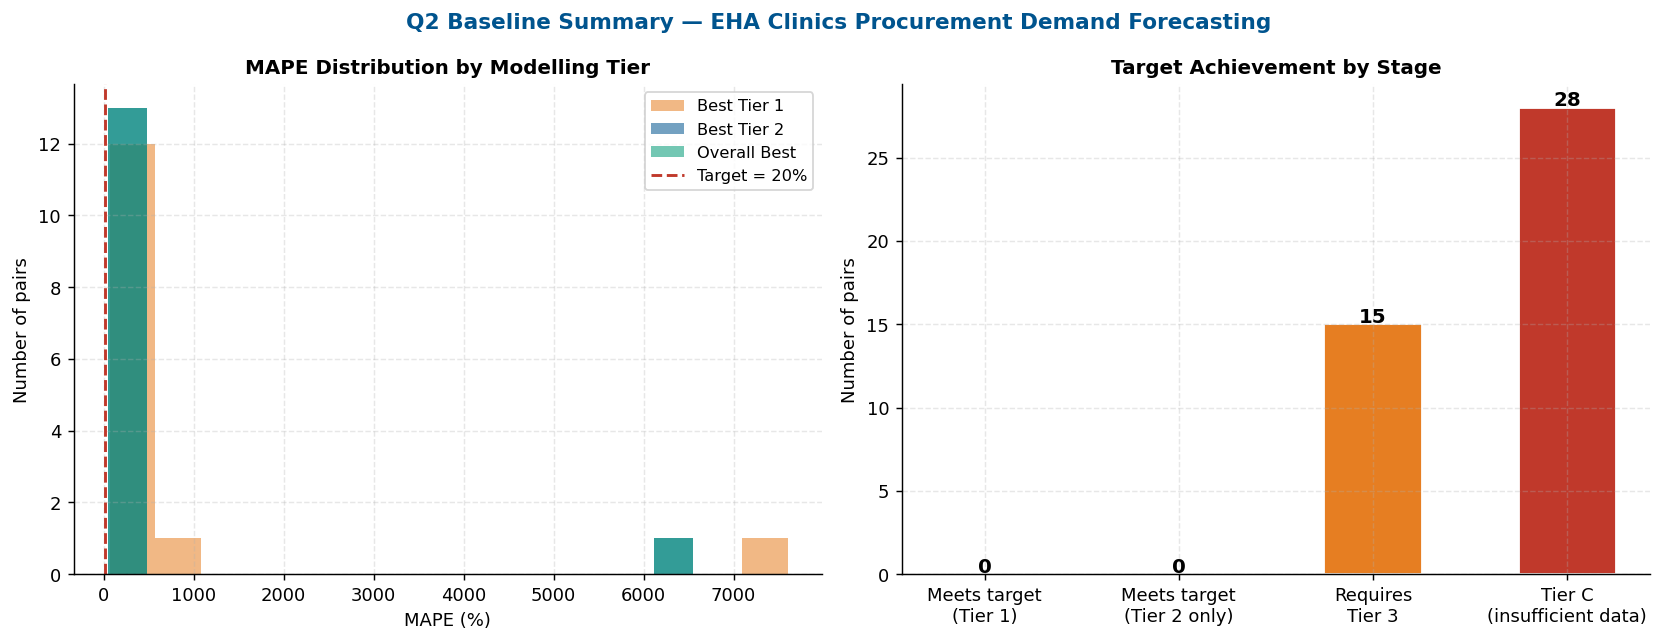


Outputs saved to: C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling\reports


In [40]:
# ── Baseline summary visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: MAPE distribution by model tier
t1_mapes = tier1['t1_best_mape'].dropna()
t2_mapes = tier2['t2_best_mape'].dropna()
best_mapes = merged['overall_best_mape'].dropna()

axes[0].hist(t1_mapes,   bins=15, alpha=0.55, color=AMBER, label='Best Tier 1')
axes[0].hist(t2_mapes,   bins=15, alpha=0.55, color=BLUE,  label='Best Tier 2')
axes[0].hist(best_mapes, bins=15, alpha=0.55, color=GREEN, label='Overall Best')
axes[0].axvline(20, color=RED, linestyle='--', linewidth=1.6, label='Target = 20%')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_ylabel('Number of pairs')
axes[0].set_title('MAPE Distribution by Modelling Tier')
axes[0].legend(fontsize=9)

# Right: Target achievement breakdown
categories = ['Meets target\n(Tier 1)', 'Meets target\n(Tier 2 only)',
              'Requires\nTier 3', 'Tier C\n(insufficient data)']
t1_met     = (tier1['t1_best_mape'] <= 20).sum()
t2_only    = ((tier2['t2_best_mape'] <= 20) & (tier1['t1_best_mape'] > 20)).sum()
need_t3    = (~merged['meets_target']).sum()
c_count    = len(tier_c)
counts = [t1_met, t2_only, need_t3, c_count]
bar_c  = [GREEN, BLUE, AMBER, RED]
axes[1].bar(categories, counts, color=bar_c, edgecolor='white', width=0.5)
for i, v in enumerate(counts):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of pairs')
axes[1].set_title('Target Achievement by Stage')

fig.suptitle('Q2 Baseline Summary — EHA Clinics Procurement Demand Forecasting',
             fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q2_baseline_summary.pdf', bbox_inches='tight')
plt.show()

print(f'\nOutputs saved to: {REPORTS_DIR}')